### Import Libraries

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statistics

### Data Load

In [47]:
df = pd.read_csv("healthcare_disease_prediction_dataset.csv")

In [48]:
df

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
0,69,Male,High,High,High,Yes,No,No,35.671099,No,1,0,0,0,1,0,0,0,0,0
1,32,Male,Low,High,Normal,Yes,No,Yes,38.554188,Yes,0,1,0,0,0,0,0,1,0,0
2,89,Female,Normal,High,Normal,No,No,Yes,18.932964,Yes,1,0,0,0,0,0,0,0,0,0
3,78,Male,High,High,High,No,No,Yes,21.806350,Yes,0,1,1,0,1,0,0,1,0,0
4,38,Male,Low,Normal,Normal,Yes,Yes,Yes,37.552683,No,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,27,Female,Low,High,Normal,No,No,No,31.960176,Yes,1,0,0,0,0,0,0,0,0,0
996,51,Female,High,High,Normal,No,Yes,Yes,20.118492,Yes,0,0,0,0,0,0,0,0,0,0
997,72,Female,Normal,High,Normal,Yes,No,No,20.916536,Yes,0,0,0,0,0,0,0,0,0,0
998,49,Male,Normal,High,High,Yes,No,Yes,19.560143,Yes,0,0,0,0,0,1,0,0,0,0


### Data Inspection

In [49]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
0,69,Male,High,High,High,Yes,No,No,35.671099,No,1,0,0,0,1,0,0,0,0,0
1,32,Male,Low,High,Normal,Yes,No,Yes,38.554188,Yes,0,1,0,0,0,0,0,1,0,0
2,89,Female,Normal,High,Normal,No,No,Yes,18.932964,Yes,1,0,0,0,0,0,0,0,0,0
3,78,Male,High,High,High,No,No,Yes,21.806350,Yes,0,1,1,0,1,0,0,1,0,0
4,38,Male,Low,Normal,Normal,Yes,Yes,Yes,37.552683,No,0,0,0,0,0,0,0,0,0,0


In [50]:
df.tail()

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
995,27,Female,Low,High,Normal,No,No,No,31.960176,Yes,1,0,0,0,0,0,0,0,0,0
996,51,Female,High,High,Normal,No,Yes,Yes,20.118492,Yes,0,0,0,0,0,0,0,0,0,0
997,72,Female,Normal,High,Normal,Yes,No,No,20.916536,Yes,0,0,0,0,0,0,0,0,0,0
998,49,Male,Normal,High,High,Yes,No,Yes,19.560143,Yes,0,0,0,0,0,1,0,0,0,0
999,67,Male,High,Normal,Normal,Yes,No,Yes,24.035803,Yes,0,1,1,0,0,0,1,1,0,0


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  1000 non-null   int64  
 1   Gender               1000 non-null   object 
 2   Blood Pressure       1000 non-null   object 
 3   Cholesterol          1000 non-null   object 
 4   Glucose              1000 non-null   object 
 5   Smoking              1000 non-null   object 
 6   Alcohol Consumption  1000 non-null   object 
 7   Exercise             1000 non-null   object 
 8   BMI                  1000 non-null   float64
 9   Family History       1000 non-null   object 
 10  Heart Disease        1000 non-null   int64  
 11  Diabetes             1000 non-null   int64  
 12  Stroke               1000 non-null   int64  
 13  Kidney Disease       1000 non-null   int64  
 14  Cancer               1000 non-null   int64  
 15  Alzheimer's Disease  1000 non-null   in

In [52]:
df.describe()

,Age,BMI,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,52.881000,29.213037,0.253000,0.186000,0.134000,0.142000,0.10000,0.130000,0.10100,0.157000,0.082000,0.035000
std,20.958915,6.196368,0.434948,0.389301,0.340823,0.349225,0.30015,0.336472,0.30148,0.363983,0.274502,0.183872
min,18.000000,18.504881,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,34.750000,23.924004,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,52.500000,28.892349,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,71.000000,34.663806,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000
max,89.000000,39.974048,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,1.000000,1.000000


In [53]:
df.shape

(1000, 20)

In [54]:
df.columns

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol', 'Glucose', 'Smoking',
       'Alcohol Consumption', 'Exercise', 'BMI', 'Family History',
       'Heart Disease', 'Diabetes', 'Stroke', 'Kidney Disease', 'Cancer',
       'Alzheimer's Disease', 'COPD', 'Liver Disease', 'Parkinson's Disease',
       'Tuberculosis'],
      dtype='object')

### Data Cleaning

#### Check Missing Values

In [30]:
df.isnull()

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [31]:
df.isnull().sum()

Age                    0
Gender                 0
Blood Pressure         0
Cholesterol            0
Glucose                0
Smoking                0
Alcohol Consumption    0
Exercise               0
BMI                    0
Family History         0
Heart Disease          0
Diabetes               0
Stroke                 0
Kidney Disease         0
Cancer                 0
Alzheimer's Disease    0
COPD                   0
Liver Disease          0
Parkinson's Disease    0
Tuberculosis           0
dtype: int64

In [32]:
df.isnull().sum().sum()

0

#### Remove Duplicates

In [34]:
df.drop_duplicates(inplace = True)

In [35]:
df

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
0,69,Male,High,High,High,Yes,No,No,35.671099,No,1,0,0,0,1,0,0,0,0,0
1,32,Male,Low,High,Normal,Yes,No,Yes,38.554188,Yes,0,1,0,0,0,0,0,1,0,0
2,89,Female,Normal,High,Normal,No,No,Yes,18.932964,Yes,1,0,0,0,0,0,0,0,0,0
3,78,Male,High,High,High,No,No,Yes,21.806350,Yes,0,1,1,0,1,0,0,1,0,0
4,38,Male,Low,Normal,Normal,Yes,Yes,Yes,37.552683,No,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,27,Female,Low,High,Normal,No,No,No,31.960176,Yes,1,0,0,0,0,0,0,0,0,0
996,51,Female,High,High,Normal,No,Yes,Yes,20.118492,Yes,0,0,0,0,0,0,0,0,0,0
997,72,Female,Normal,High,Normal,Yes,No,No,20.916536,Yes,0,0,0,0,0,0,0,0,0,0
998,49,Male,Normal,High,High,Yes,No,Yes,19.560143,Yes,0,0,0,0,0,1,0,0,0,0


### Data Transformation

##### Convert categorical ---> numeric (for analysis)

In [55]:
df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df['Smoking'] = df['Smoking'].map({'Yes':1, 'No':0})
df['Alcohol Consumption'] = df['Alcohol Consumption'].map({'Yes':1, 'No':0})
df['Exercise'] = df['Exercise'].map({'Yes':1, 'No':0})
df['Family History'] = df['Family History'].map({'Yes':1, 'No':0})

In [56]:
df

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,Heart Disease,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis
0,69,1,High,High,High,1,0,0,35.671099,0,1,0,0,0,1,0,0,0,0,0
1,32,1,Low,High,Normal,1,0,1,38.554188,1,0,1,0,0,0,0,0,1,0,0
2,89,0,Normal,High,Normal,0,0,1,18.932964,1,1,0,0,0,0,0,0,0,0,0
3,78,1,High,High,High,0,0,1,21.806350,1,0,1,1,0,1,0,0,1,0,0
4,38,1,Low,Normal,Normal,1,1,1,37.552683,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,27,0,Low,High,Normal,0,0,0,31.960176,1,1,0,0,0,0,0,0,0,0,0
996,51,0,High,High,Normal,0,1,1,20.118492,1,0,0,0,0,0,0,0,0,0,0
997,72,0,Normal,High,Normal,1,0,0,20.916536,1,0,0,0,0,0,0,0,0,0,0
998,49,1,Normal,High,High,1,0,1,19.560143,1,0,0,0,0,0,1,0,0,0,0


#### Create Age Group

In [57]:
df['Age_Group'] = pd.cut(df['Age'], bins=[0,30,50,70,100], labels=['Young','Adult','Senior','Old'])

In [58]:
df['Age_Group']

0      Senior
1       Adult
2         Old
3         Old
4       Adult
        ...  
995     Young
996    Senior
997       Old
998     Adult
999    Senior
Name: Age_Group, Length: 1000, dtype: category
Categories (4, object): ['Young' < 'Adult' < 'Senior' < 'Old']

### EDA (Exploratory Data Analysis)

#### Disease Distribution

In [59]:
diseases = ['Heart Disease','Diabetes','Stroke','Cancer']

for d in diseases:
    print(df[d].value_counts())

Heart Disease
0    747
1    253
Name: count, dtype: int64
Diabetes
0    814
1    186
Name: count, dtype: int64
Stroke
0    866
1    134
Name: count, dtype: int64
Cancer
0    900
1    100
Name: count, dtype: int64


#### Lifestyle vs Disease

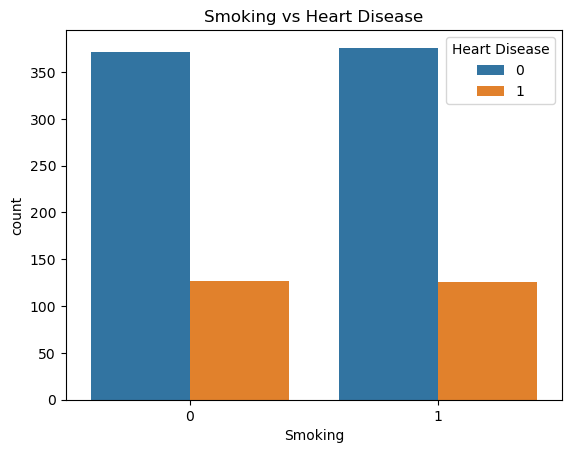

In [61]:
sns.countplot(x='Smoking', hue='Heart Disease', data=df)
plt.title("Smoking vs Heart Disease")
plt.show()

### Data Visualization

#### Age Distribution 

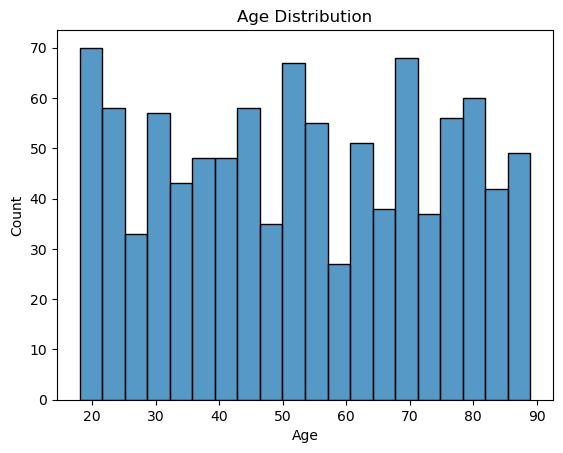

In [62]:
sns.histplot(df['Age'], bins=20)
plt.title("Age Distribution")
plt.show()

#### BMI vs Disease

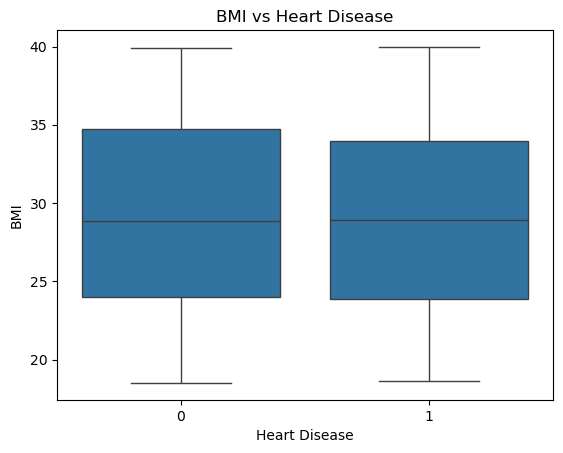

In [63]:
sns.boxplot(x='Heart Disease', y='BMI', data=df)
plt.title("BMI vs Heart Disease")
plt.show()

#### Gender vs Disease

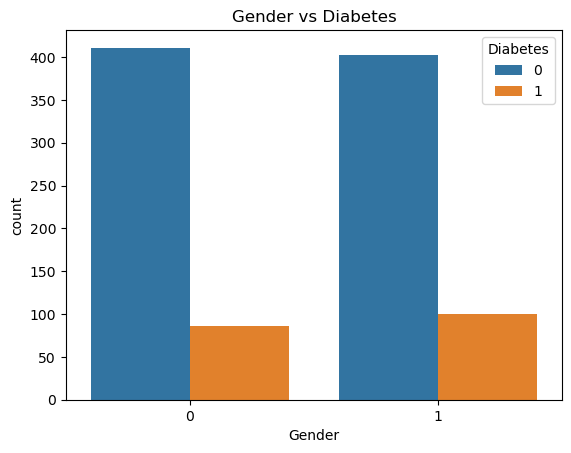

In [64]:
sns.countplot(x='Gender', hue='Diabetes', data=df)
plt.title("Gender vs Diabetes")
plt.show()

#### Exercise Impact 

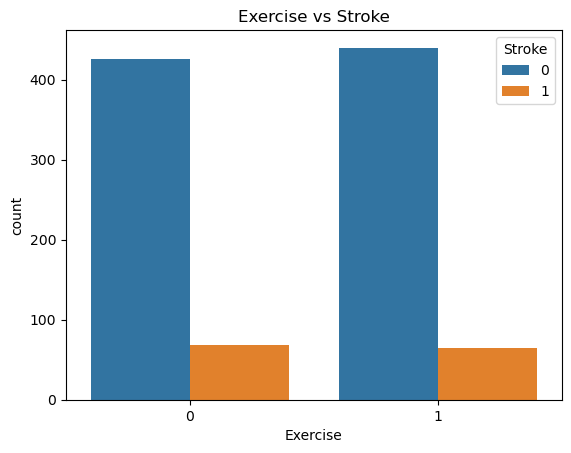

In [65]:
sns.countplot(x='Exercise', hue='Stroke', data=df)
plt.title("Exercise vs Stroke")
plt.show()

### Explore Clean Data 

In [66]:
df.to_csv("clean_healthcare_data.csv", index=False)

In [67]:
df

,Age,Gender,Blood Pressure,Cholesterol,Glucose,Smoking,Alcohol Consumption,Exercise,BMI,Family History,...,Diabetes,Stroke,Kidney Disease,Cancer,Alzheimer's Disease,COPD,Liver Disease,Parkinson's Disease,Tuberculosis,Age_Group
0,69,1,High,High,High,1,0,0,35.671099,0,...,0,0,0,1,0,0,0,0,0,Senior
1,32,1,Low,High,Normal,1,0,1,38.554188,1,...,1,0,0,0,0,0,1,0,0,Adult
2,89,0,Normal,High,Normal,0,0,1,18.932964,1,...,0,0,0,0,0,0,0,0,0,Old
3,78,1,High,High,High,0,0,1,21.806350,1,...,1,1,0,1,0,0,1,0,0,Old
4,38,1,Low,Normal,Normal,1,1,1,37.552683,0,...,0,0,0,0,0,0,0,0,0,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,27,0,Low,High,Normal,0,0,0,31.960176,1,...,0,0,0,0,0,0,0,0,0,Young
996,51,0,High,High,Normal,0,1,1,20.118492,1,...,0,0,0,0,0,0,0,0,0,Senior
997,72,0,Normal,High,Normal,1,0,0,20.916536,1,...,0,0,0,0,0,0,0,0,0,Old
998,49,1,Normal,High,High,1,0,1,19.560143,1,...,0,0,0,0,1,0,0,0,0,Adult
